In [6]:
import pandas as pd

df1 = pd.read_csv("insurance_claims.csv")
df2 = pd.read_csv("fraud_oracle.csv")

In [7]:
df1.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [8]:
df2.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [9]:
print("Insurance Claims:", df1.shape)
print("Fraud Oracle:", df2.shape)

Insurance Claims: (1000, 40)
Fraud Oracle: (15420, 33)


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [12]:
df2["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [13]:
df2["FraudFound_P"].value_counts(normalize=True) * 100

FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64

In [14]:
df2.duplicated().sum()

np.int64(0)

In [16]:
print(df2["FraudFound_P"].value_counts())

print(df2["FraudFound_P"].value_counts(normalize=True) * 100)

print(df2.duplicated().sum())

FraudFound_P
0    14497
1      923
Name: count, dtype: int64
FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64
0


In [17]:
df1["fraud_reported"].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [18]:
df1["fraud_reported"].value_counts(normalize=True) * 100

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

In [19]:
df1.duplicated().sum()

np.int64(0)

## Check Missing Values

In [20]:
df1.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [21]:
df1.isnull().sum()[df1.isnull().sum() > 0]

authorities_contacted      91
_c39                     1000
dtype: int64

In [23]:
(df1 == "?").sum()[((df1 == "?").sum() > 0)]

collision_type             178
property_damage            360
police_report_available    343
dtype: int64

In [24]:
df1["authorities_contacted"].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64

In [25]:
df1["authorities_contacted"] = df1["authorities_contacted"].fillna(
    df1["authorities_contacted"].mode()[0]
)

In [26]:
df1["authorities_contacted"].isnull().sum()

np.int64(0)

In [27]:
df1.isnull().sum()[df1.isnull().sum() > 0]

_c39    1000
dtype: int64

In [28]:
df1 = df1.drop(columns="_c39")

In [29]:
df1.isnull().sum()[df1.isnull().sum() > 0]

Series([], dtype: int64)

In [30]:
df1.nunique().sort_values()

fraud_reported                    2
insured_sex                       2
police_report_available           3
bodily_injuries                   3
policy_state                      3
policy_csl                        3
policy_deductable                 3
property_damage                   3
witnesses                         4
number_of_vehicles_involved       4
authorities_contacted             4
incident_severity                 4
incident_type                     4
collision_type                    4
insured_relationship              6
incident_city                     7
incident_state                    7
insured_education_level           7
umbrella_limit                   11
auto_make                        14
insured_occupation               14
insured_hobbies                  20
auto_year                        21
incident_hour_of_the_day         24
auto_model                       39
age                              46
incident_date                    60
capital-gains               

In [32]:
df1["collision_type"] = df1["collision_type"].replace("?", pd.NA)
df1["property_damage"] = df1["property_damage"].replace("?", pd.NA)
df1["police_report_available"] = df1["police_report_available"].replace("?", pd.NA)

In [33]:
df1.isnull().sum()[df1.isnull().sum() > 0]

collision_type             178
property_damage            360
police_report_available    343
dtype: int64

In [34]:
df1["collision_type"] = df1["collision_type"].fillna(
    df1["collision_type"].mode()[0]
)

df1["property_damage"] = df1["property_damage"].fillna(
    df1["property_damage"].mode()[0]
)

df1["police_report_available"] = df1["police_report_available"].fillna(
    df1["police_report_available"].mode()[0]
)

In [35]:
df1.isnull().sum()[df1.isnull().sum() > 0]

Series([], dtype: int64)

In [36]:
df2.isnull().sum()[df2.isnull().sum() > 0]

Series([], dtype: int64)

In [37]:
(df2 == "?").sum()[((df2 == "?").sum() > 0)]

Series([], dtype: int64)

In [40]:
df1_ml = df1.drop(columns=[
    "policy_number",
    "insured_zip",
    "incident_location"
])

In [41]:
df1_ml.shape

(1000, 36)

In [42]:
df1_ml["policy_bind_date"] = pd.to_datetime(df1_ml["policy_bind_date"])

df1_ml["incident_date"] = pd.to_datetime(df1_ml["incident_date"])

In [43]:
df1_ml[["policy_bind_date", "incident_date"]].dtypes

policy_bind_date    datetime64[ns]
incident_date       datetime64[ns]
dtype: object

In [44]:
df1_ml["policy_bind_year"] = df1_ml["policy_bind_date"].dt.year
df1_ml["policy_bind_month"] = df1_ml["policy_bind_date"].dt.month

df1_ml["incident_year"] = df1_ml["incident_date"].dt.year
df1_ml["incident_month"] = df1_ml["incident_date"].dt.month

In [45]:
df1_ml = df1_ml.drop(columns=[
    "policy_bind_date",
    "incident_date"
])

In [46]:
df1_ml.shape

(1000, 38)

In [47]:
X1 = df1_ml.drop(columns="fraud_reported")
y1 = df1_ml["fraud_reported"]

In [48]:
print(X1.shape)
print(y1.shape)

(1000, 37)
(1000,)


In [49]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [50]:
print(X1_train.shape)
print(X1_test.shape)
print(y1_train.shape)
print(y1_test.shape)

(800, 37)
(200, 37)
(800,)
(200,)


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [54]:
from sklearn.model_selection import train_test_split

# Features
X = df1.drop("fraud_reported", axis=1)

# Target
y = df1["fraud_reported"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 38)
(200, 38)
(800,)
(200,)


In [56]:
X_train.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year'],
      dtype='object')

In [57]:
X = df1.drop(["fraud_reported", "policy_number"], axis=1)

y = df1["fraud_reported"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 37)
(200, 37)


In [58]:
numerical_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 17
Categorical columns: 20


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [60]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['months_as_customer', 'age', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total...
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [61]:
y_pred_logistic = logistic_model.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logistic))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_logistic))

Accuracy: 0.79

Classification Report:

              precision    recall  f1-score   support

           N       0.83      0.91      0.87       151
           Y       0.60      0.43      0.50        49

    accuracy                           0.79       200
   macro avg       0.72      0.67      0.68       200
weighted avg       0.77      0.79      0.78       200


Confusion Matrix:

[[137  14]
 [ 28  21]]


In [63]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['months_as_customer', 'age', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total...
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [64]:
y_pred_rf = random_forest_model.predict(X_test)

In [65]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.74

Classification Report:

              precision    recall  f1-score   support

           N       0.76      0.95      0.85       151
           Y       0.36      0.08      0.13        49

    accuracy                           0.74       200
   macro avg       0.56      0.52      0.49       200
weighted avg       0.66      0.74      0.67       200


Confusion Matrix:

[[144   7]
 [ 45   4]]


In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df1 = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    "Precision (Fraud)": [
        precision_score(y_test, y_pred_logistic, pos_label="Y"),
        precision_score(y_test, y_pred_rf, pos_label="Y")
    ],
    
    "Recall (Fraud)": [
        recall_score(y_test, y_pred_logistic, pos_label="Y"),
        recall_score(y_test, y_pred_rf, pos_label="Y")
    ],
    
    "F1-score (Fraud)": [
        f1_score(y_test, y_pred_logistic, pos_label="Y"),
        f1_score(y_test, y_pred_rf, pos_label="Y")
    ]
})

comparison_df1

,Model,Accuracy,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
0,Logistic Regression,0.79,0.600000,0.428571,0.500000
1,Random Forest,0.74,0.363636,0.081633,0.133333


In [67]:
X2 = df2.drop("FraudFound_P", axis=1)
y2 = df2["FraudFound_P"]

from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print(X2_train.shape)
print(X2_test.shape)
print(y2_train.shape)
print(y2_test.shape)

(12336, 32)
(3084, 32)
(12336,)
(3084,)


In [68]:
numerical_cols2 = X2_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols2 = X2_train.select_dtypes(
    include=['object', 'category']
).columns

print("Numerical columns:", len(numerical_cols2))
print("Categorical columns:", len(categorical_cols2))

Numerical columns: 8
Categorical columns: 24


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols2),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols2)
    ]
)

In [70]:
logistic_model2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model2.fit(X2_train, y2_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Year'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex'...alStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [71]:
y2_pred_logistic = logistic_model2.predict(X2_test)

In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y2_test, y2_pred_logistic))

print("\nClassification Report:\n")
print(classification_report(y2_test, y2_pred_logistic))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y2_test, y2_pred_logistic))

Accuracy: 0.940337224383917

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.67      0.01      0.02       185

    accuracy                           0.94      3084
   macro avg       0.80      0.51      0.50      3084
weighted avg       0.92      0.94      0.91      3084


Confusion Matrix:

[[2898    1]
 [ 183    2]]


In [73]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

random_forest_model2.fit(X2_train, y2_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Year'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex'...
       'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [74]:
y2_pred_rf = random_forest_model2.predict(X2_test)

print("Accuracy:", accuracy_score(y2_test, y2_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y2_test, y2_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y2_test, y2_pred_rf))

Accuracy: 0.940337224383917

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.97      0.50      0.49      3084
weighted avg       0.94      0.94      0.91      3084


Confusion Matrix:

[[2899    0]
 [ 184    1]]


In [75]:
comparison_df2 = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y2_test, y2_pred_logistic),
        accuracy_score(y2_test, y2_pred_rf)
    ],

    "Precision (Fraud)": [
        precision_score(y2_test, y2_pred_logistic, pos_label=1),
        precision_score(y2_test, y2_pred_rf, pos_label=1)
    ],

    "Recall (Fraud)": [
        recall_score(y2_test, y2_pred_logistic, pos_label=1),
        recall_score(y2_test, y2_pred_rf, pos_label=1)
    ],

    "F1-score (Fraud)": [
        f1_score(y2_test, y2_pred_logistic, pos_label=1),
        f1_score(y2_test, y2_pred_rf, pos_label=1)
    ]
})

comparison_df2

,Model,Accuracy,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
0,Logistic Regression,0.940337,0.666667,0.010811,0.021277
1,Random Forest,0.940337,1.000000,0.005405,0.010753


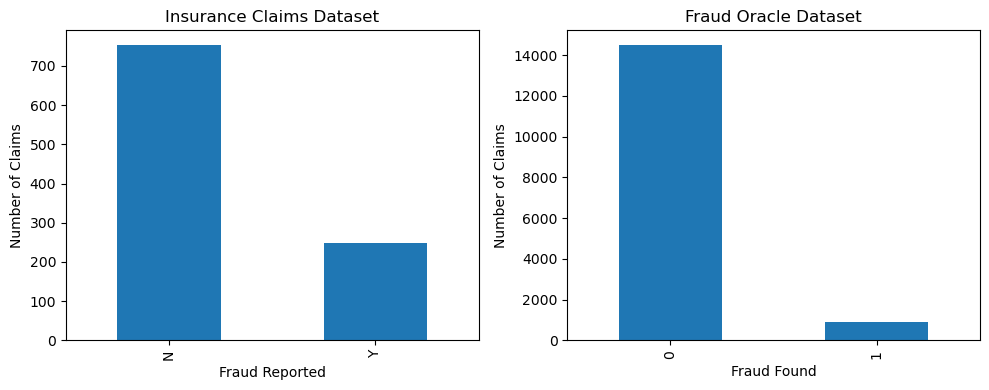

In [76]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(10, 4))

# Dataset 1
plt.subplot(1, 2, 1)

df1["fraud_reported"].value_counts().plot(
    kind="bar"
)

plt.title("Insurance Claims Dataset")
plt.xlabel("Fraud Reported")
plt.ylabel("Number of Claims")

# Dataset 2
plt.subplot(1, 2, 2)

df2["FraudFound_P"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud Oracle Dataset")
plt.xlabel("Fraud Found")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

In [78]:
[name for name in globals() if 'model' in name.lower() or 'logistic' in name.lower() or 'rf' in name.lower()]

['LogisticRegression',
 'logistic_model',
 'y_pred_logistic',
 'random_forest_model',
 'y_pred_rf',
 'logistic_model2',
 'y2_pred_logistic',
 'random_forest_model2',
 'y2_pred_rf']

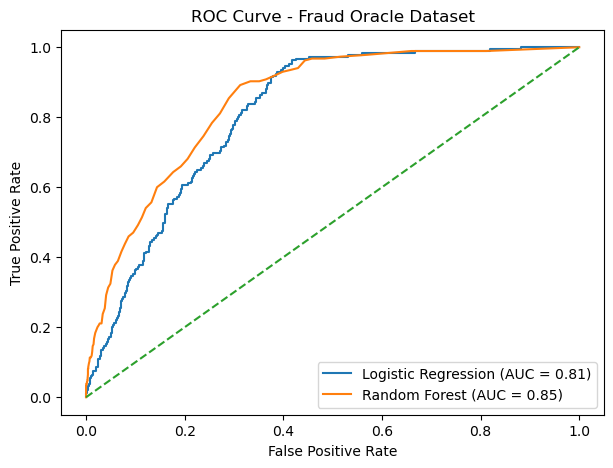

In [79]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y2_prob_logistic = logistic_model2.predict_proba(X2_test)[:, 1]
y2_prob_rf = random_forest_model2.predict_proba(X2_test)[:, 1]

# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(y2_test, y2_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y2_test, y2_prob_rf)

# Calculate AUC
auc_logistic = auc(fpr_logistic, tpr_logistic)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {auc_logistic:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.2f})'
)

# Reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fraud Oracle Dataset')
plt.legend()

plt.show()

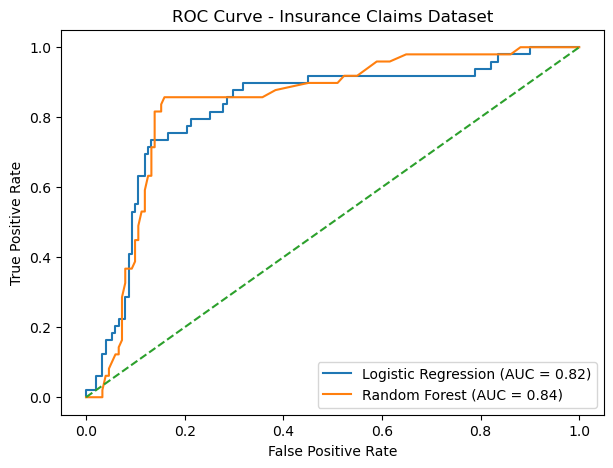

In [81]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
# pos_label='Y' means Y = fraudulent claim
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic,
    pos_label='Y'
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf,
    pos_label='Y'
)

# Calculate AUC scores
auc_logistic = auc(fpr_logistic, tpr_logistic)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {auc_logistic:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.2f})'
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Insurance Claims Dataset')
plt.legend()

plt.show()

In [82]:
plt.savefig("insurance_claims_roc.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [83]:
plt.savefig("fraud_oracle_roc.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>